# Librerías

In [36]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import SimpleITK as sitk

# Configuración

In [37]:
DATA_PATH = "data"

ANNOTATIONS_PATH = os.path.join(DATA_PATH, "annotations.csv")
CANDIDATES_PATH = os.path.join(DATA_PATH, "candidates.csv")

TRAIN_LIST = "splits/train.txt"

OUTPUT_DIR = "dataset_train"

POSITIVE_DIR = os.path.join(OUTPUT_DIR,"positive")
NEGATIVE_DIR = os.path.join( OUTPUT_DIR,"negative")

os.makedirs(POSITIVE_DIR, exist_ok=True)
os.makedirs(NEGATIVE_DIR, exist_ok=True)

PATCH_SIZE = 64

OFFSET_XY_MM = 8
OFFSET_Z_MM = 4

N_OFFSETS = 5

NEGATIVE_RATIO = 3

DISTANCIA_MAX_MM = 2

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Leer archivos

In [38]:
annotations = pd.read_csv(ANNOTATIONS_PATH)
candidates = pd.read_csv(CANDIDATES_PATH)
with open(TRAIN_LIST) as f:
    train_ct = set(
        line.strip()
        for line in f
    )
print("Annotations:", len(annotations))
print("Candidates:", len(candidates))
print("CT Train:", len(train_ct))

Annotations: 1186
Candidates: 551065
CT Train: 620


## Filtrar solamente train

In [39]:
annotations_train = annotations[
    annotations["seriesuid"].isin(train_ct)
].copy()

candidates_train = candidates[
    candidates["seriesuid"].isin(train_ct)
].copy()

print("Annotations train:", len(annotations_train))
print("Candidates train:", len(candidates_train))

Annotations train: 821
Candidates train: 389114


## Construcción de positivos

In [40]:
candidates_positive = candidates_train[
    candidates_train["class"] == 1
].copy()

print(len(candidates_positive))

925


## Eliminar candidatos duplicados

In [41]:
indices_eliminar = []

for idx, row in candidates_positive.iterrows():

    nodulos = annotations_train[
        annotations_train["seriesuid"] == row["seriesuid"]
    ]

    if len(nodulos) == 0:
        continue

    distancias = np.sqrt(

        (nodulos.coordX-row.coordX)**2 +

        (nodulos.coordY-row.coordY)**2 +

        (nodulos.coordZ-row.coordZ)**2

    )

    if distancias.min() <= DISTANCIA_MAX_MM:

        indices_eliminar.append(idx)

candidates_positive = candidates_positive.drop(indices_eliminar)

print("Candidates positivos finales:",len(candidates_positive))

Candidates positivos finales: 251


## Unir annotations + candidates

In [42]:
annotations_train["source"] = "annotation"
candidates_positive["source"] = "candidate"
candidates_positive["diameter_mm"] = np.nan

positive_df = pd.concat(
    [
        annotations_train[[
            "seriesuid",
            "coordX",
            "coordY",
            "coordZ",
            "diameter_mm",
            "source"
        ]],

        candidates_positive[[
            "seriesuid",
            "coordX",
            "coordY",
            "coordZ",
            "diameter_mm",
            "source"
        ]]
    ],
    ignore_index=True
)

print("Positivos finales:",len(positive_df))

Positivos finales: 1072


# Construcción de negativos

In [43]:
ct_con_nodulo = set(
    annotations_train.seriesuid.unique()
)

negative_df = candidates_train[
    (candidates_train["class"]==0)
    &
    (~candidates_train["seriesuid"].isin(ct_con_nodulo))
].copy()

print(len(negative_df))

122680


## Balance 3:1

In [44]:
n_positive = len(positive_df)
n_negative = NEGATIVE_RATIO * n_positive

ct_sanas = negative_df["seriesuid"].unique()

print("CT sanas:", len(ct_sanas))

negativos_por_ct = int(
    np.ceil(
        n_negative / len(ct_sanas)
    )
)

print("Negativos por CT:", negativos_por_ct)

negative_balanceado = []

for ct in ct_sanas:

    candidatos_ct = negative_df[
        negative_df["seriesuid"] == ct
    ]

    n = min(
        len(candidatos_ct),
        negativos_por_ct
    )

    negative_balanceado.append(
        candidatos_ct.sample(
            n=n,
            random_state=42
        )
    )

negative_df = pd.concat(
    negative_balanceado,
    ignore_index=True
)

print("Negativos finales:", len(negative_df))

CT sanas: 200
Negativos por CT: 17
Negativos finales: 3400


In [45]:
print()

print("Positivos:",len(positive_df))

print("Negativos:",len(negative_df))

print("Ratio:",

      len(negative_df)/len(positive_df)
)


Positivos: 1072
Negativos: 3400
Ratio: 3.171641791044776


## Buscar automáticamente la tomografía

In [46]:
ct_paths = {}

for subset in range(10):

    folder = os.path.join(
        DATA_PATH,
        f"subset{subset}"
    )

    for file in os.listdir(folder):

        if file.endswith(".mhd"):

            seriesuid = file.replace(".mhd","")

            ct_paths[seriesuid] = os.path.join(
                folder,
                file
            )

print(len(ct_paths))

888


# Extraer patch

In [47]:
def extract_patch(volume, center, patch_size=64):

    z, y, x = center
    h = patch_size // 2

    z = max(h, min(z, volume.shape[0] - h))
    y = max(h, min(y, volume.shape[1] - h))
    x = max(h, min(x, volume.shape[2] - h))

    patch = volume[
        z-h:z+h,
        y-h:y+h,
        x-h:x+h
    ]

    return patch

## Random Offset

In [48]:
def random_offset(voxel, spacing):

    z, y, x = voxel

    oz = random.randint(
        -round(OFFSET_Z_MM / spacing[2]),
         round(OFFSET_Z_MM / spacing[2])
    )

    oy = random.randint(
        -round(OFFSET_XY_MM / spacing[1]),
         round(OFFSET_XY_MM / spacing[1])
    )

    ox = random.randint(
        -round(OFFSET_XY_MM / spacing[0]),
         round(OFFSET_XY_MM / spacing[0])
    )

    return (
        z + oz,
        y + oy,
        x + ox
    )

# Extraer patches positivos

In [49]:
dataset_info = []
patch_id = 0
seriesuid_list = positive_df["seriesuid"].unique()

In [50]:
def preprocess(volume):

    volume = np.clip(volume,-1000,400)
    volume = (volume + 1000) / 1400

    return volume.astype(np.float32)

In [51]:
for seriesuid in tqdm(seriesuid_list):

    # Buscar la tomografía
    mhd_path = ct_paths.get(seriesuid)

    if mhd_path is None:
        continue

    # Leer CT una sola vez
    sitk_img = sitk.ReadImage(mhd_path)

    volume = sitk.GetArrayFromImage(sitk_img).astype(np.float32)

    # Windowing
    volume = preprocess(volume)

    origin = sitk_img.GetOrigin()
    spacing = sitk_img.GetSpacing()

    # Positivos de esta CT
    positivos_ct = positive_df[
        positive_df["seriesuid"] == seriesuid
    ]

    for _, row in positivos_ct.iterrows():

        voxelX = int(
            (row.coordX - origin[0]) / spacing[0]
        )

        voxelY = int(
            (row.coordY - origin[1]) / spacing[1]
        )

        voxelZ = int(
            (row.coordZ - origin[2]) / spacing[2]
        )

        # Generar varios offsets
        for _ in range(N_OFFSETS):

            centro = random_offset(
                (voxelZ, voxelY, voxelX),
                spacing
            )

            patch = extract_patch(
                volume,
                centro,
                PATCH_SIZE
            )

            filename = f"patch_{patch_id:06d}.npy"

            np.save(
                os.path.join(
                    POSITIVE_DIR,
                    filename
                ),
                patch
            )

            dataset_info.append({
                "patch": f"positive/{filename}",
                "seriesuid": seriesuid,
                "label": 1,
                "source": row.source,
                "diameter_mm": row.diameter_mm
            })

            patch_id += 1

100%|██████████| 420/420 [04:45<00:00,  1.47it/s]


In [52]:
negative_seriesuid = negative_df["seriesuid"].unique()

for seriesuid in tqdm(negative_seriesuid):

    # Buscar la tomografía
    mhd_path = ct_paths.get(seriesuid)

    if mhd_path is None:
        continue

    # Leer CT una sola vez
    sitk_img = sitk.ReadImage(mhd_path)

    volume = sitk.GetArrayFromImage(sitk_img).astype(np.float32)

    # Windowing
    volume = preprocess(volume)

    origin = sitk_img.GetOrigin()
    spacing = sitk_img.GetSpacing()

    # Todos los negativos de esta CT
    negativos_ct = negative_df[
        negative_df["seriesuid"] == seriesuid
    ]

    for _, row in negativos_ct.iterrows():

        voxelX = int(
            (row.coordX - origin[0]) / spacing[0]
        )

        voxelY = int(
            (row.coordY - origin[1]) / spacing[1]
        )

        voxelZ = int(
            (row.coordZ - origin[2]) / spacing[2]
        )

        centro = random_offset(
            (voxelZ, voxelY, voxelX),
            spacing
        )

        patch = extract_patch(
            volume,
            centro,
            PATCH_SIZE
        )

        filename = f"patch_{patch_id:06d}.npy"

        np.save(
            os.path.join(
                NEGATIVE_DIR,
                filename
            ),
            patch
        )

        dataset_info.append({
            "patch": f"negative/{filename}",
            "seriesuid": seriesuid,
            "label": 0,
            "source": "candidate",
            "diameter_mm": np.nan
        })

        patch_id += 1

100%|██████████| 200/200 [02:34<00:00,  1.30it/s]


In [53]:
dataset_train = pd.DataFrame(dataset_info)

dataset_train.to_csv(
    "dataset_train.csv",
    index=False
)

print("DATASET TRAIN CREADO")

print("Total patches:", len(dataset_train))

print(dataset_train["label"].value_counts())

print(dataset_train["source"].value_counts())

DATASET TRAIN CREADO
Total patches: 8760
label
1    5360
0    3400
Name: count, dtype: int64
source
candidate     4655
annotation    4105
Name: count, dtype: int64


# Validar

In [54]:
import numpy as np
import os

patch = np.load(
    os.path.join(
        POSITIVE_DIR,
        os.listdir(POSITIVE_DIR)[0]
    )
)

print(patch.shape)

(64, 64, 64)


In [55]:
print(patch.min())
print(patch.max())

0.0
1.0


In [56]:
(volume+1000)/1400

array([[[0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        ...,
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573]],

       [[0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        ...,
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.7

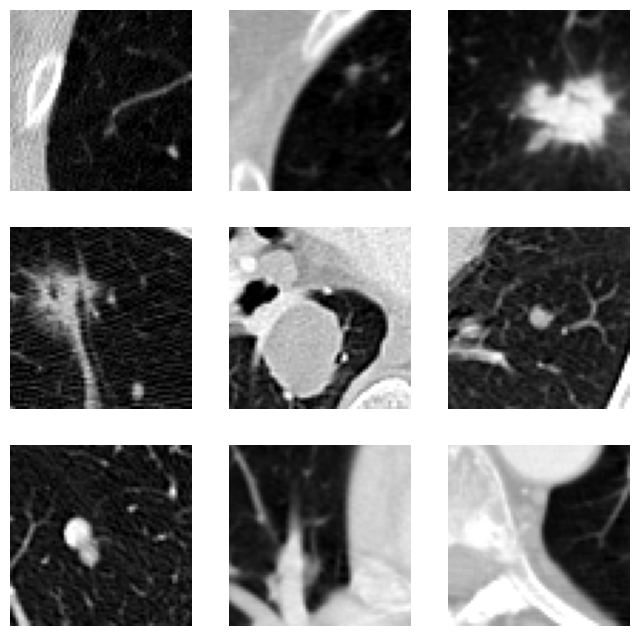

In [58]:
import random

files = random.sample(
    os.listdir(POSITIVE_DIR),
    9
)

fig,ax = plt.subplots(3,3,figsize=(8,8))

for i,file in enumerate(files):

    p = np.load(
        os.path.join(POSITIVE_DIR,file)
    )

    ax.flat[i].imshow(
        p[32],
        cmap="gray"
    )

    ax.flat[i].axis("off")

plt.show()

In [60]:
vacios = []

for file in os.listdir(POSITIVE_DIR):

    p = np.load(os.path.join(POSITIVE_DIR,file))

    if np.all(p == 0):
        vacios.append(file)

print(len(vacios))

150


In [61]:
vacios_neg = []

for file in os.listdir(NEGATIVE_DIR):

    p = np.load(os.path.join(NEGATIVE_DIR,file))

    if np.all(p == 0):
        vacios_neg.append(file)

print(len(vacios_neg))

17
